# **DATA WRANGLING 2**
Create an “Academic performance” dataset of students and perform the following operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal
with them.
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be
one of the following reasons: to change the scale for better understanding of the variable, to convert a
non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal
distribution.
4. Reason and document your approach properly.



In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Student_ID":[1,2,3,4,5,6,7,8,9,10],
    "Study_Hours":[2,4,6,8,np.nan,5,7,20,3,4],
    "Attendance":[85,90,88,95,80,78,92,110,75,np.nan],
    "Assignment_Score":[70,75,80,85,90,65,72,95,68,74],
    "Exam_Score":[65,70,78,88,92,60,75,98,66,72],
    "Gender":["M","F","M","F","F","M","M","F","F","M"]
}

df = pd.DataFrame(data)
print(df)

   Student_ID  Study_Hours  Attendance  Assignment_Score  Exam_Score Gender
0           1          2.0        85.0                70          65      M
1           2          4.0        90.0                75          70      F
2           3          6.0        88.0                80          78      M
3           4          8.0        95.0                85          88      F
4           5          NaN        80.0                90          92      F
5           6          5.0        78.0                65          60      M
6           7          7.0        92.0                72          75      M
7           8         20.0       110.0                95          98      F
8           9          3.0        75.0                68          66      F
9          10          4.0         NaN                74          72      M


In [4]:
print(df.isnull().sum())

Student_ID          0
Study_Hours         1
Attendance          1
Assignment_Score    0
Exam_Score          0
Gender              0
dtype: int64


In [5]:
df["Study_Hours"].fillna(df["Study_Hours"].mean(), inplace=True)
df["Attendance"].fillna(df["Attendance"].mean(), inplace=True)

/tmp/ipykernel_7304/2418863968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Study_Hours"].fillna(df["Study_Hours"].mean(), inplace=True)
/tmp/ipykernel_7304/2418863968.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [6]:
print(df.isnull().sum())

Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Exam_Score          0
Gender              0
dtype: int64


In [7]:
print(df[df["Attendance"] > 100])

   Student_ID  Study_Hours  Attendance  Assignment_Score  Exam_Score Gender
7           8         20.0       110.0                95          98      F


In [8]:
df.loc[df["Attendance"] > 100, "Attendance"] = 100

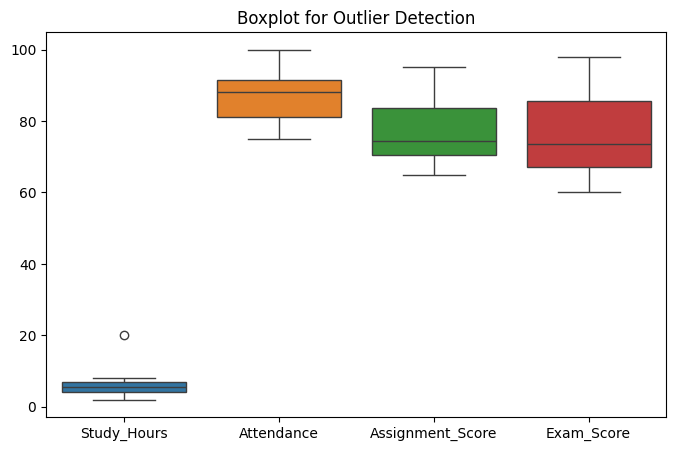

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Study_Hours","Attendance","Assignment_Score","Exam_Score"]])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [10]:
Q1 = df["Study_Hours"].quantile(0.25)
Q3 = df["Study_Hours"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Study_Hours"] = np.where(df["Study_Hours"] > upper, upper, df["Study_Hours"])

In [11]:
df["Exam_Percentage"] = (df["Exam_Score"] / 100) * 100

In [12]:
df["Log_Study_Hours"] = np.log(df["Study_Hours"])

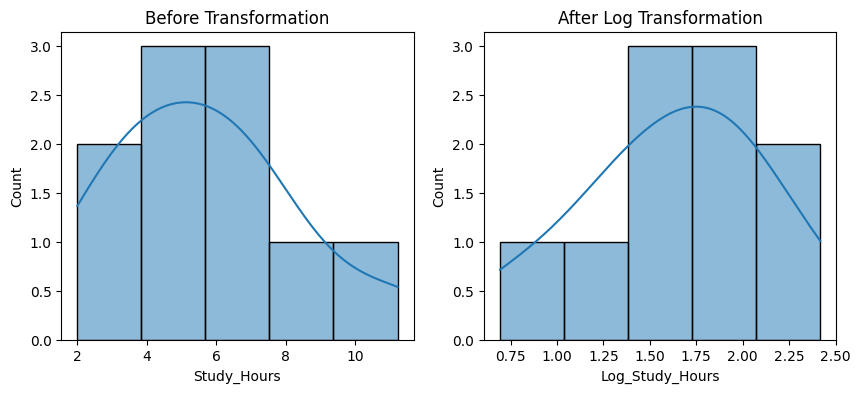

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["Study_Hours"], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df["Log_Study_Hours"], kde=True)
plt.title("After Log Transformation")

plt.show()

In [14]:
print(df)

   Student_ID  Study_Hours  Attendance  Assignment_Score  Exam_Score Gender  \
0           1     2.000000   85.000000                70          65      M   
1           2     4.000000   90.000000                75          70      F   
2           3     6.000000   88.000000                80          78      M   
3           4     8.000000   95.000000                85          88      F   
4           5     6.555556   80.000000                90          92      F   
5           6     5.000000   78.000000                65          60      M   
6           7     7.000000   92.000000                72          75      M   
7           8    11.222222  100.000000                95          98      F   
8           9     3.000000   75.000000                68          66      F   
9          10     4.000000   88.111111                74          72      M   

   Exam_Percentage  Log_Study_Hours  
0             65.0         0.693147  
1             70.0         1.386294  
2             78